### Import Libaries

In [371]:
import requests
import pandas as pd

In [372]:
base_url = "https://pokeapi.co/api/v2/"

def get_pokemon_of_type(type):
    url = f"{base_url}/type/{type}"
    response = requests.get(url)

    if response.status_code == 200:
        print(f"{type}-type Pokemon retrieved!")
        pokemon_data = response.json()
        return pokemon_data
    else:
        print(f"Failed to retrieve {type}-type Pokemon!")
    


In [373]:
ATTACK = 1
def get_pokemon_attack(url):
    pokemon_url = url
    response = requests.get(url)

    if response.status_code == 200:
        pokemon_data = response.json()
        stats = pokemon_data["stats"]
        attack = stats[ATTACK]["base_stat"]

        return attack


In [374]:
HP = 0
def get_pokemon_hp(url):
    pokemon_url = url
    response = requests.get(url)

    if response.status_code == 200:
        pokemon_data = response.json()
        stats = pokemon_data["stats"]
        hp = stats[HP]["base_stat"]

        return hp

In [375]:
def get_pokemon_weight(url):
    pokemon_url = url
    response = requests.get(url)

    if response.status_code == 200:
        pokemon_data = response.json()
        weight = pokemon_data["weight"]

        return weight

In [376]:
def get_pokemon_height(url):
    pokemon_url = url
    response = requests.get(url)

    if response.status_code == 200:
        pokemon_data = response.json()
        height = pokemon_data["height"]

        return height

In [377]:
def get_pokemon_data(pokemon_list, names_arr, attack_arr, hp_arr, weight_arr, height_arr):
    for pokemon in pokemon_list:
        pokemon_record = pokemon["pokemon"]
        pokemon_name = pokemon_record["name"]
        pokemon_url = pokemon_record["url"]
        attack = get_pokemon_attack(pokemon_url)
        hp = get_pokemon_hp(pokemon_url)
        height = get_pokemon_height(pokemon_url)
        weight = get_pokemon_weight(pokemon_url)
        names_arr.append(pokemon_name)
    
        attack_arr.append(attack)
        hp_arr.append(hp)
        weight_arr.append(weight)
        height_arr.append(height)

### Get bug-type pokemon from the api

In [378]:
bug_types = get_pokemon_of_type("bug")
bug_type_pokemon = bug_types["pokemon"]
bug_type_pokemon_names = []
bug_type_pokemon_attack = []
bug_type_pokemon_hp = []
bug_type_pokemon_weight = []
bug_type_pokemon_height = []
get_pokemon_data(bug_type_pokemon, bug_type_pokemon_names, bug_type_pokemon_attack, bug_type_pokemon_hp, bug_type_pokemon_weight, bug_type_pokemon_height)

bug-type Pokemon retrieved!


In [379]:
print(bug_type_pokemon_names[0:15])
print(bug_type_pokemon_attack[0:15])
print(bug_type_pokemon_hp[0:15])
print(bug_type_pokemon_weight[0:15])
print(bug_type_pokemon_height[0:15])

['caterpie', 'metapod', 'butterfree', 'weedle', 'kakuna', 'beedrill', 'paras', 'parasect', 'venonat', 'venomoth', 'scyther', 'pinsir', 'ledyba', 'ledian', 'spinarak']
[30, 20, 45, 35, 25, 90, 70, 95, 55, 65, 110, 125, 20, 35, 60]
[45, 50, 60, 40, 45, 65, 35, 60, 60, 70, 70, 65, 40, 55, 40]
[29, 99, 320, 32, 100, 295, 54, 295, 300, 125, 560, 550, 108, 356, 85]
[3, 7, 11, 3, 6, 10, 3, 10, 10, 15, 15, 15, 10, 14, 5]


### Get rock-type pokemon

In [380]:
rock_types = get_pokemon_of_type("rock")
rock_type_pokemon = rock_types["pokemon"]
rock_type_pokemon_names = []
rock_type_pokemon_attack = []
rock_type_pokemon_hp = []
rock_type_pokemon_weight = []
rock_type_pokemon_height = []
get_pokemon_data(rock_type_pokemon, rock_type_pokemon_names, rock_type_pokemon_attack, rock_type_pokemon_hp, rock_type_pokemon_weight, rock_type_pokemon_height)

rock-type Pokemon retrieved!


In [381]:
print(rock_type_pokemon_names[0:15])
print(rock_type_pokemon_attack[0:15])
print(rock_type_pokemon_hp[0:15])
print(rock_type_pokemon_weight[0:15])
print(rock_type_pokemon_height[0:15])

['geodude', 'graveler', 'golem', 'onix', 'rhyhorn', 'rhydon', 'omanyte', 'omastar', 'kabuto', 'kabutops', 'aerodactyl', 'sudowoodo', 'shuckle', 'magcargo', 'corsola']
[80, 95, 120, 45, 85, 130, 40, 60, 80, 115, 105, 100, 10, 50, 55]
[40, 55, 80, 35, 80, 105, 35, 70, 30, 60, 80, 70, 20, 60, 65]
[200, 1050, 3000, 2100, 1150, 1200, 75, 350, 115, 405, 590, 380, 205, 550, 50]
[4, 10, 14, 88, 10, 19, 4, 10, 5, 13, 18, 12, 6, 8, 6]


### Building DataFrames

#### DataFrame for Bug Type

In [382]:
bug_type_df = pd.DataFrame(
    {
        "name": bug_type_pokemon_names,
        "attack": bug_type_pokemon_attack,
        "hp" : bug_type_pokemon_hp,
        "weight": bug_type_pokemon_weight,
        "height": bug_type_pokemon_height
    }
)
bug_type_df.loc[:, 'type'] = 'bug'
bug_type_df.loc[:, 'target'] = 1
bug_type_df[:5]

,name,attack,hp,weight,height,type,target
0,caterpie,30,45,29,3,bug,1
1,metapod,20,50,99,7,bug,1
2,butterfree,45,60,320,11,bug,1
3,weedle,35,40,32,3,bug,1
4,kakuna,25,45,100,6,bug,1


#### DataFrame for Rock Type

In [383]:
rock_type_df = pd.DataFrame(
    {
        "name": rock_type_pokemon_names,
        "attack": rock_type_pokemon_attack,
        "hp" : rock_type_pokemon_hp,
        "weight": rock_type_pokemon_weight,
        "height": rock_type_pokemon_height
    }
)
rock_type_df.loc[:, 'type'] = 'rock'
rock_type_df.loc[:, 'target'] = 0
rock_type_df[:5]

,name,attack,hp,weight,height,type,target
0,geodude,80,40,200,4,rock,0
1,graveler,95,55,1050,10,rock,0
2,golem,120,80,3000,14,rock,0
3,onix,45,35,2100,88,rock,0
4,rhyhorn,85,80,1150,10,rock,0


In [384]:
final_df = pd.concat([bug_type_df, rock_type_df])
final_df = final_df[~final_df["name"].str.contains("gmax")]
final_df = final_df[~final_df["name"].str.contains("mega")]
final_df = final_df[~final_df["name"].str.contains("totem")]
# final_df = final_df[final_df["weight"] < 4000]
# final_df = final_df[final_df["height"] < 400]
final_df = final_df.drop_duplicates(subset=['name'], keep=False)
final_df

,name,attack,hp,weight,height,type,target
0,caterpie,30,45,29,3,bug,1
1,metapod,20,50,99,7,bug,1
2,butterfree,45,60,320,11,bug,1
3,weedle,35,40,32,3,bug,1
4,kakuna,25,45,100,6,bug,1
...,...,...,...,...,...,...,...
95,lycanroc-dusk,117,75,250,8,rock,0
98,growlithe-hisui,75,60,227,8,rock,0
99,arcanine-hisui,115,95,1680,20,rock,0
100,avalugg-hisui,127,95,2624,14,rock,0


In [385]:
final_rock_df = final_df[final_df["target"] == 0]
final_bug_df = final_df[final_df["target"] == 1]

In [386]:
# Check duplicates
# Crustle is both rock and bug type-pokemon
# It's gotta be removed
final_df[final_df["name"] == "crustle"]

,name,attack,hp,weight,height,type,target


### Plots

In [387]:
import matplotlib.pyplot as plt
%matplotlib inline

### HP vs Attack

Text(0.5, 1.0, 'HP vs Attack')

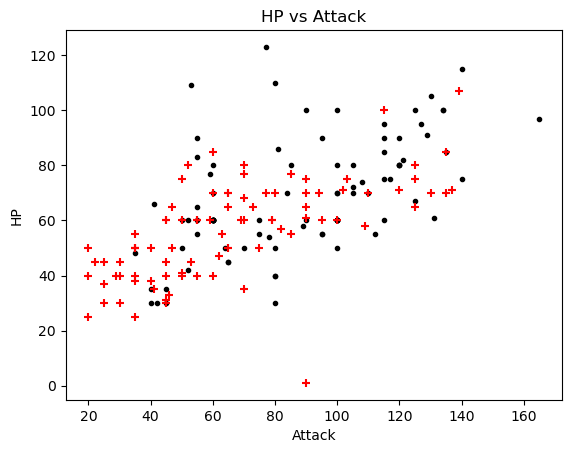

In [388]:
plt.xlabel("Attack")
plt.ylabel("HP")

plt.scatter(final_rock_df["attack"], final_rock_df["hp"], color="black", marker=".")
plt.scatter(final_bug_df["attack"], final_bug_df["hp"], color="red", marker="+")
plt.title("HP vs Attack")

### Weight vs Height

Text(0.5, 1.0, 'Height vs Weight')

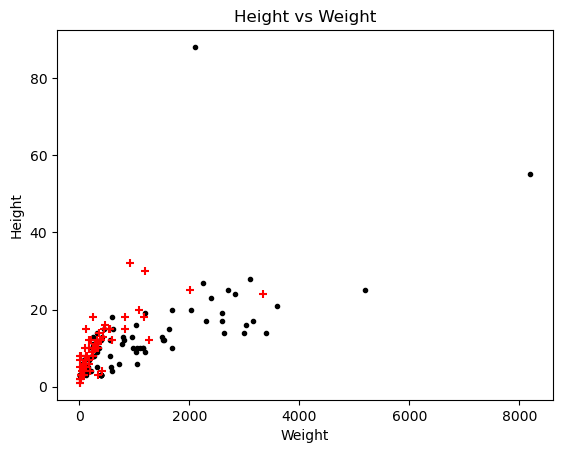

In [389]:
plt.xlabel("Weight")
plt.ylabel("Height")
plt.scatter(final_rock_df["weight"], final_rock_df["height"], color="black", marker=".")
plt.scatter(final_bug_df["weight"], final_bug_df["height"], color="red", marker="+")
plt.title("Height vs Weight")


## K nearest neighbors classification

### Get the features and target variable

In [390]:
from sklearn.model_selection import train_test_split

In [391]:
X_weight_height = final_df.drop(['type', 'name', 'attack', 'hp', 'target'], axis='columns')
y = final_df.type

X_weight_height[0:5]

,weight,height
0,29,3
1,99,7
2,320,11
3,32,3
4,100,6


In [392]:
y[0:5]

0    bug
1    bug
2    bug
3    bug
4    bug
Name: type, dtype: object

In [393]:
X_train, X_test, y_train, y_test = train_test_split(X_weight_height, y, test_size=0.2, random_state=20)
print("Training: ")
print(len(X_train))
print(X_train[:3])

print("Testing: ")
print(len(X_test))
print(X_test[:3])

Training: 
142
    weight  height
1       99       7
73     120       5
98     227       8
Testing: 
36
     weight  height
25      604      15
101     398      12
50     2005      25


### Build the Classifier - Using height & Weight as Features

In [394]:
from sklearn.neighbors import KNeighborsClassifier
knn_weight_height = KNeighborsClassifier(n_neighbors=10)
knn_weight_height.fit(X_train, y_train)

,n_neighbors,10
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [395]:
knn_weight_height.score(X_test, y_test)

0.6111111111111112

### Testing Model with Real Pokemon (Features: weight and height)

<img src="https://raw.githubusercontent.com/PokeAPI/sprites/master/sprites/pokemon/74.png" height="200" width="200"/>


**Weight**: 200
**Height**: 4

<img src="https://raw.githubusercontent.com/PokeAPI/sprites/master/sprites/pokemon/10.png" height="200" width="200">

**Weight**: 29
**Height**: 3

<img src="https://raw.githubusercontent.com/PokeAPI/sprites/master/sprites/pokemon/540.png" height="300" width="300">

**Weight**: 25
**Height**: 3

<img src="https://raw.githubusercontent.com/PokeAPI/sprites/master/sprites/pokemon/305.png" height="300" width="300"/>


**Weight**: 1200
**Height**: 9

<img src="https://raw.githubusercontent.com/PokeAPI/sprites/master/sprites/pokemon/304.png" height="200" width="200">

**Weight**: 600
**Height**: 4

In [396]:
print("--- Enter Weight and Height of Pokemon and we will tell you its type! ---")
print("--- Bug vs Ground ---")
weight = input("weight in hectograms: ")
height = input("height in decimetres: ")
input_df = pd.DataFrame(
    {
        "weight": [weight],
        "height": [height]
    }
)
print("\nInput: ")
print(input_df)
type = knn_weight_height.predict(input_df)
print(f"\nType: {type}!!!!")


--- Enter Weight and Height of Pokemon and we will tell you its type! ---
--- Bug vs Ground ---

Input: 
  weight height
0     29      3

Type: ['bug']!!!!


### How good is our model?

In [397]:
from sklearn.metrics import confusion_matrix
y_pred = knn_weight_height.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
cm

array([[ 8,  7],
       [ 7, 14]])

Text(58.222222222222214, 0.5, 'Real Type')

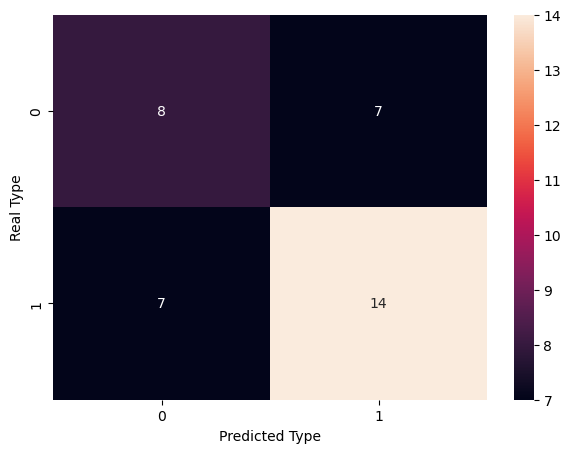

In [398]:
import seaborn as sb
plt.figure(figsize=(7,5))
sb.heatmap(cm, annot=True)
plt.xlabel("Predicted Type")
plt.ylabel("Real Type")


### Building Classifier - Using Attack and HP

In [399]:
X_attack_hp = final_df.drop(['type', 'weight', 'height', 'name', 'target'], axis='columns')
y = final_df.type

X_attack_hp[:5]

,attack,hp
0,30,45
1,20,50
2,45,60
3,35,40
4,25,45


In [400]:
y[:5]

0    bug
1    bug
2    bug
3    bug
4    bug
Name: type, dtype: object

In [401]:
X_train, X_test, y_train, y_test = train_test_split(X_attack_hp, y, test_size=0.2, random_state=20)
knn = KNeighborsClassifier(n_neighbors=12)
knn.fit(X_train, y_train)

,n_neighbors,12
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


### Testing Model with Real Pokemon (Features: Attack and HP)


<img src="https://raw.githubusercontent.com/PokeAPI/sprites/master/sprites/pokemon/74.png" height="200" width="200">

Attack: 110
HP: 70

<img src="https://raw.githubusercontent.com/PokeAPI/sprites/master/sprites/pokemon/10.png" height="200" width="200">

**Attack**: 30
**HP**: 45

<img src="https://raw.githubusercontent.com/PokeAPI/sprites/master/sprites/pokemon/540.png" height="300" width="300">

Attack: 53
HP: 45

<img src="https://raw.githubusercontent.com/PokeAPI/sprites/master/sprites/pokemon/305.png" height="300" width="300"/>

Attack: 90
HP: 60

<img src="https://raw.githubusercontent.com/PokeAPI/sprites/master/sprites/pokemon/304.png" height="200" width="200">

Attack: 50
HP: 70

In [402]:
### Find the type 
print("--- Enter Attack and HP of Pokemon and we will tell you its type! ---")
print("--- Bug vs Ground ---")
attack = input("attack: ")
hp = input("hp: ")
input_df = pd.DataFrame(
    {
        "attack": [attack],
        "hp": [hp]
    }
)
print("\nInput: ")
print(input_df)
type = knn.predict(input_df)
print(f"\nType: {type}!!!!")

--- Enter Attack and HP of Pokemon and we will tell you its type! ---
--- Bug vs Ground ---

Input: 
  attack  hp
0     90  60

Type: ['rock']!!!!


### How good is our model?

In [403]:
knn.score(X_test, y_test)

0.8333333333333334

In [404]:
y_pred = knn.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
cm

array([[14,  1],
       [ 5, 16]])

Text(58.222222222222214, 0.5, 'Real Type')

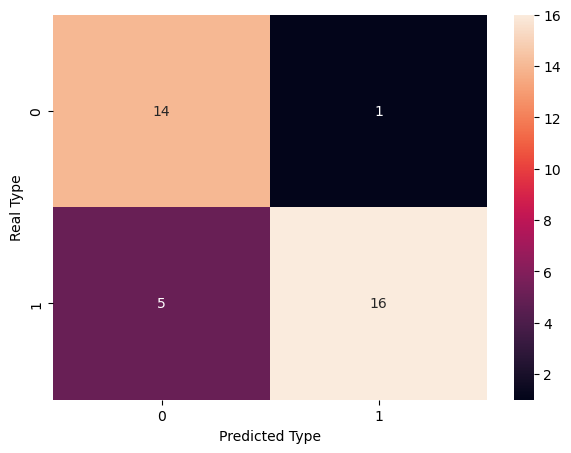

In [405]:
import seaborn as sb
plt.figure(figsize=(7,5))
sb.heatmap(cm, annot=True)
plt.xlabel("Predicted Type")
plt.ylabel("Real Type")

### Testing our model with real pokemon!

In [406]:
print("----- Enter ")

----- Enter 
